Training TS2Vec unsupervised representations...
Epoch #0: loss=209151.14716256075
Epoch #1: loss=3.7523579350833236
Epoch #2: loss=4.553310821796286
Epoch #3: loss=66.29907056380962
Epoch #4: loss=1214639.4634720786
Epoch #5: loss=10190.814323318416
Epoch #6: loss=148611.4868003171
Epoch #7: loss=3.665360015014122
Epoch #8: loss=39932.427372373386
Epoch #9: loss=3.6456546536807357
Encoding chronological features per symbol...


/Users/kai/studies/ts2vec/ts2vec.py:270: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  dataset = TensorDataset(torch.from_numpy(data).to(torch.float))


Training CatBoost on 489391 samples, testing on 177957 samples...
0:	learn: 251.6893777	total: 97ms	remaining: 48.4s
100:	learn: 119.5366012	total: 2.15s	remaining: 8.51s
200:	learn: 56.6016510	total: 4.24s	remaining: 6.31s
300:	learn: 26.7317516	total: 6.41s	remaining: 4.24s
400:	learn: 12.7203298	total: 8.56s	remaining: 2.11s
499:	learn: 6.2473283	total: 10.7s	remaining: 0us

--- Test Set Cumulative Performance (Net of 0.2% Fees) ---
CatBoost + TS2Vec L/S Strategy : 759.14%
Buy & Hold Baseline            : -65.28%


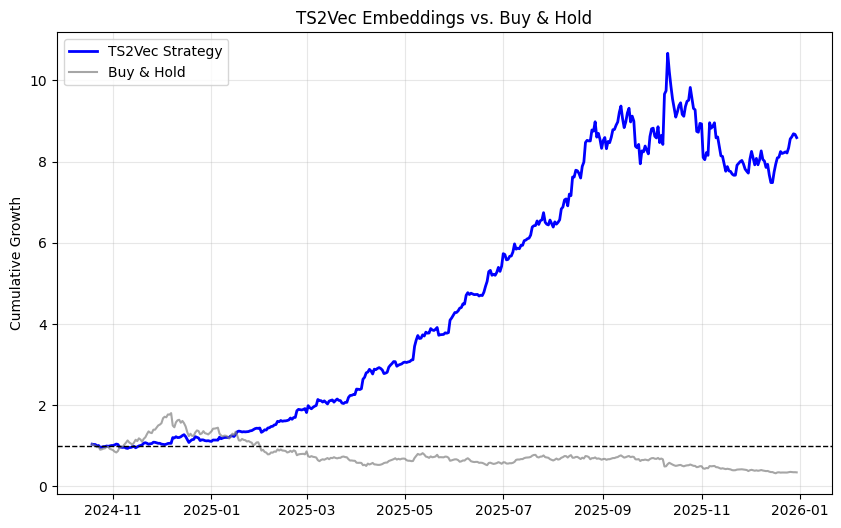

In [2]:
# ts2vec feature engineering

from ts2vec.ts2vec import TS2Vec

import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
import datetime
import numpy as np
import polars as pl


# 1. Add the cloned 'ts2vec' directory to Python's path
# This ensures TS2Vec's internal imports (like 'import models') work correctly


# You will need the TS2Vec class from the official repository

df = pl.read_parquet('usdt1d.parquet').filter(
    (pl.col('ts').dt.year() >= 2020) & (pl.col('ts').dt.year() <= 2025)).select(['symbol', 'ts', 'close'])
symbols = df["symbol"].unique().to_list()
symbols = ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT']

# ==========================================
# 2. PREP DATA (RETURNS & TARGETS)
# ==========================================
# Neural networks struggle with raw, unscaled prices. We convert to returns.
df = df.sort(["symbol", "ts"]).with_columns([
    pl.col("close").pct_change().over("symbol").alias("ret_1d"),
])

# Target: The actual return of the NEXT day
df = df.with_columns([
    pl.col("ret_1d").shift(-1).over("symbol").alias("target_next_ret")
]).drop_nulls()  # Drops the first day (no return) and last day (no target)

# ==========================================
# 3. CHRONOLOGICAL SPLIT & TENSOR CONVERSION
# ==========================================
unique_dates = df["ts"].unique().sort()
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_df = df.filter(pl.col("ts") < split_date)
test_df = df.filter(pl.col("ts") >= split_date)

# ==========================================
# 4. TS2Vec: TRAIN ON UNBALANCED DATA
# ==========================================
print("Training TS2Vec unsupervised representations...")
ts2vec_model = TS2Vec(input_dims=1, device='cpu', output_dims=64)

# To train the foundation model, we pad shorter symbols with 0s at the beginning


def create_padded_tensor(data_df):
    arrays = []
    # Find the longest surviving symbol
    max_len = data_df.group_by("symbol").agg(pl.col("ts").count())["ts"].max()

    for sym, group in data_df.group_by("symbol"):
        arr = group["ret_1d"].to_numpy()
        # Pad zeros at the start of the array to match max_len
        padded = np.pad(arr, (max_len - len(arr), 0), 'constant')
        arrays.append(padded)

    return np.stack(arrays)[..., np.newaxis]


X_train_padded = create_padded_tensor(train_df)
# Train TS2Vec on the padded data
loss_log = ts2vec_model.fit(X_train_padded, n_epochs=10, verbose=True)

# ==========================================
# 5. ENCODE & ALIGN PERFECTLY FOR CATBOOST
# ==========================================
# We encode symbol-by-symbol to ignore the padding and extract the true dates.
# This guarantees our tabular matrix matches the DataFrame height exactly.


def extract_aligned_features(data_df, model):
    # Sort is mandatory to match Polars' internal order
    data_df = data_df.sort(["symbol", "ts"])

    all_embeds = []
    targets = []

    # maintain_order=True processes groups in the exact order of the sorted df
    for sym, group in data_df.group_by("symbol", maintain_order=True):
        arr = group["ret_1d"].to_numpy().reshape(1, -1, 1)

        # causal=True ensures no future leakage during chronological extraction
        emb = model.encode(arr, causal=True)

        all_embeds.append(emb.reshape(-1, 64))
        targets.append(group["target_next_ret"].to_numpy())

    return np.vstack(all_embeds), np.concatenate(targets), data_df


print("Encoding chronological features per symbol...")
X_train_tabular, y_train, train_df = extract_aligned_features(
    train_df, ts2vec_model)
X_test_tabular, y_test, test_df = extract_aligned_features(
    test_df, ts2vec_model)

# ==========================================
# 6. TRAIN CATBOOST
# ==========================================
print(
    f"Training CatBoost on {len(X_train_tabular)} samples, testing on {len(X_test_tabular)} samples...")
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    verbose=100
)

cb_model.fit(X_train_tabular, y_train)

# ==========================================
# 7. STRATEGY EVALUATION (NET OF FEES)
# ==========================================
preds = cb_model.predict(X_test_tabular)

fee_rate = 0.002  # 0.2% entry and exit fee

# Sort to ensure strict chronological order per symbol
test_df = test_df.sort(["symbol", "ts"])

# 1. Define predictions and intended positions
test_df = test_df.with_columns([
    pl.Series("pred_ret", preds)
])

# Long (+1) if pred > 0, Short (-1) if pred < 0
test_df = test_df.with_columns([
    pl.when(pl.col("pred_ret") > 0).then(1).otherwise(-1).alias("position")
])

# 2. Calculate Position Changes
# Shift position down by 1 to see what we held yesterday.
# fill_null(0) assumes we start in cash (0) before our first trade.
test_df = test_df.with_columns([
    pl.col("position").shift(1).fill_null(
        0).over("symbol").alias("prev_position")
])

# 3. Calculate Transaction Costs
# Math: If we go from +1 to -1, the absolute difference is 2.
# 2 * 0.002 = 0.004 (0.4% total fee to flip the position).
test_df = test_df.with_columns([
    ((pl.col("position") - pl.col("prev_position")).abs() * fee_rate).alias("tx_fees")
])

# 4. Calculate Net Returns
# Strategy Return = Gross Return - Transaction Fees
test_df = test_df.with_columns([
    (pl.col("position") * pl.col("target_next_ret") -
     pl.col("tx_fees")).alias("strategy_ret"),
    pl.col("target_next_ret").alias("bnh_ret")
])

# 5. Aggregate portfolio performance per day across all symbols
portfolio_daily = test_df.group_by("ts").agg([
    pl.col("strategy_ret").mean(),
    pl.col("bnh_ret").mean()
]).sort("ts")

# 6. Calculate Cumulative Returns
portfolio_daily = portfolio_daily.with_columns([
    (1 + pl.col("strategy_ret")).cum_prod().alias("cum_strategy"),
    (1 + pl.col("bnh_ret")).cum_prod().alias("cum_bnh")
])

final_strat = portfolio_daily["cum_strategy"][-1] - 1
final_bnh = portfolio_daily["cum_bnh"][-1] - 1

print(f"\n--- Test Set Cumulative Performance (Net of 0.2% Fees) ---")
print(f"CatBoost + TS2Vec L/S Strategy : {final_strat * 100:.2f}%")
print(f"Buy & Hold Baseline            : {final_bnh * 100:.2f}%")

# ==========================================
# 8. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(portfolio_daily["ts"], portfolio_daily["cum_strategy"],
         label="TS2Vec Strategy", color="blue", linewidth=2)
plt.plot(portfolio_daily["ts"], portfolio_daily["cum_bnh"],
         label="Buy & Hold", color="gray", alpha=0.7)
plt.axhline(1.0, color='black', linestyle='--', linewidth=1)
plt.title("TS2Vec Embeddings vs. Buy & Hold")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# chronos-2 feature engineering

import polars as pl
import numpy as np
import torch
from chronos import Chronos2Pipeline
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from numpy.lib.stride_tricks import sliding_window_view  # <-- Added for fast rolling windows

print(df)
# 1. POLARS: HIGH-SPEED FEATURE ENGINEERING
# We calculate 30d momentum and target returns efficiently per symbol
def engineer_features(df: pl.DataFrame):
    return df.sort(["symbol", "ts"]).with_columns([
        # 30-period momentum (e.g., 30 days if daily, 30 hours if hourly)
        (pl.col("close") / pl.col("close").shift(30) - 1).over("symbol").alias("momentum_30d"),
        
        # Target: Log-returns for the next period
        (pl.col("close").log().diff().shift(-1).over("symbol")).alias("target_next_ret"),
        
        # Volatility as a scaling feature
        (pl.col("close").log().diff().rolling_std(window_size=20).over("symbol")).alias("vol_20p")
    ]).drop_nulls()

# 2. CHRONOS-2: GENERATE TEMPORAL EMBEDDINGS
# Chronos-2 "sees" the raw price action to find patterns manual features miss
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="auto")

def get_all_chronos_embeddings(df, lookback=128, batch_size=64):
    prices = df['close'].to_numpy()
    windows = sliding_window_view(prices, window_shape=lookback)
    num_windows = len(windows)
    
    print(f"DEBUG: Total rows in df: {len(df)}")
    print(f"DEBUG: Total windows to process: {num_windows}")
    
    all_embeddings = []
    
    with torch.no_grad():
        for i in range(0, num_windows, batch_size):
            batch_windows = windows[i : i + batch_size]
            
            tensor_input = torch.tensor(batch_windows, dtype=torch.float32).unsqueeze(1)
            
            embeddings, _ = pipeline.embed(tensor_input)
            batched_embeddings = torch.stack(embeddings)
            
            mean_embeds = batched_embeddings.mean(dim=-2).view(len(batch_windows), -1).cpu().numpy()
            all_embeddings.append(mean_embeds)
            
            # Print just the first batch to verify shape
            if i == 0:
                print(f"DEBUG: First batch array shape: {mean_embeds.shape}")
                
    # If the loop actually finishes, this will print
    print(f"DEBUG: Loop finished! Total batches stored: {len(all_embeddings)}")
    
    final_matrix = np.vstack(all_embeddings)
    print(f"DEBUG: Final stacked matrix shape: {final_matrix.shape}")
    
    return final_matrix

        
# 3. EVALUATION: ANNUALIZED SHARPE RATIO
def compute_sharpe(preds, actuals, periods_per_year=365):
    # Long-Short Strategy: Go long if pred > 0, short if pred < 0
    strategy_returns = np.sign(preds) * actuals
    
    mean_ret = np.mean(strategy_returns)
    std_ret = np.std(strategy_returns) + 1e-9
    
    sharpe = (mean_ret / std_ret) * np.sqrt(periods_per_year)
    return sharpe

# ==========================================
# MAIN EXECUTION 
# ==========================================

# Assuming 'df' is already loaded in your environment
df_feat = engineer_features(df)
lookback = 128

# 1. Get Chronos embeddings for the whole dataset
print("Generating Chronos embeddings... (This might take a minute depending on data size)")
deep_features = get_all_chronos_embeddings(df_feat, lookback=lookback, batch_size=64) 

# 2. Align Polars data perfectly by dropping the first (lookback - 1) rows
# We use standard slicing [offset:] which Polars supports directly
manual_features = df_feat.select(["momentum_30d", "vol_20p"])[lookback - 1:].to_numpy()

# 3. CONCATENATE into the final 'X' matrix
# Shapes are now aligned: [N_rows, Chronos_Dim] + [N_rows, Manual_Dim]
X = np.hstack([deep_features, manual_features])

# 4. Define the target 'y' (aligned by dropping first rows)
y = df_feat.select("target_next_ret")[lookback - 1:].to_numpy().flatten()

# 5. TRAINING & VALIDATION SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

print(f"\nData successfully shaped!")
print(f"Training on {len(X_train)} samples, testing on {len(X_test)} samples...\n")

# 6. MODEL TRAINING
model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=100)
model.fit(X_train, y_train, eval_set=(X_test, y_test))

# 7. FINAL PERFORMANCE CHECK
test_preds = model.predict(X_test)
final_sharpe = compute_sharpe(test_preds, y_test)

print(f"\n--- Strategy Results ---")
print(f"Annualized Sharpe Ratio: {final_sharpe:.2f}")